# TT-14 — ElasticNet (L1 + L2): Dự báo tải sưởi/làm mát toà nhà khi các biến thiết kế dính chặt nhau

**Bài toán:** công ty thiết kế cần ước tính tải sưởi (Y1) và tải làm mát (Y2) của một
toà nhà ngay từ bản vẽ, trước khi xây, để chọn công suất điều hoà phù hợp. Chọn thừa
công suất gây lãng phí đầu tư và tốn điện; chọn thiếu khiến toà nhà không đủ mát/ấm,
phải cải tạo rất tốn kém.

**Đặc thù dữ liệu:** các biến thiết kế (diện tích tường, diện tích mái, chiều cao,
diện tích sàn...) dính chặt nhau về mặt hình học — đổi một biến kéo theo các biến khác
đổi theo do ràng buộc vật lý. Đây chính là kịch bản mà **Lasso** (TT-13) xử lý tệ: khi
hai biến tương quan cao, Lasso chọn ngẫu nhiên một biến và bỏ hẳn biến kia, có thể loại
nhầm một biến quan trọng chỉ vì nó "thua" biến song sinh của nó trong một lần chạy cụ
thể. **ElasticNet** kết hợp cả phạt L1 (Lasso) và L2 (Ridge) để vừa loại được biến vô
dụng, vừa **giữ cả nhóm** biến tương quan (hiệu ứng gom nhóm — grouping effect).

**Bộ dữ liệu:** [Energy Efficiency (UCI)](https://archive.ics.uci.edu/dataset/242/energy+efficiency)
— 768 dòng, 8 đặc trưng thiết kế (`X1`–`X8`), 2 nhãn hồi quy (`Y1` = tải sưởi,
`Y2` = tải làm mát).

## Công thức ElasticNet và vì sao nó giải quyết đúng điểm yếu của Lasso

```
   ElasticNet = trộn CẢ HAI hình phạt:

        Loss = MSE + λ·[ ρ·Σ|wᵢ|  +  (1−ρ)/2·Σwᵢ² ]
                        └─ L1 ─┘      └─── L2 ───┘

        ρ (l1_ratio) = 1   → giống hệt LASSO
        ρ = 0              → giống hệt RIDGE
        ρ = 0,5            → cân bằng cả hai
```

| | Ridge | Lasso | **ElasticNet** |
|---|---|---|---|
| Đưa hệ số về 0 | ❌ | ✅ | ✅ |
| Giữ nhóm biến tương quan | ✅ | ❌ | ✅ |
| Khi số biến > số mẫu | Kém | Tối đa n biến | ✅ Tốt nhất |

Thành phần L2 trong ElasticNet "kéo" các hệ số của biến tương quan lại gần nhau thay vì
để L1 loại bỏ ngẫu nhiên một biến trong nhóm — đó là cơ chế của hiệu ứng gom nhóm mà bài
này sẽ kiểm chứng bằng số liệu thật ở bước 6.

In [1]:
%matplotlib inline
import io
import json
import urllib.request
import zipfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet, ElasticNetCV, Lasso, LassoCV, LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

RANDOM_STATE = 42
DATA_URL = "https://archive.ics.uci.edu/static/public/242/energy+efficiency.zip"
DATA_XLSX = Path("../data/ENB2012_data.xlsx")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True, parents=True)

FEATURE_NUMERIC = ["X1", "X2", "X3", "X4", "X5", "X7"]
FEATURE_CATEGORICAL = ["X6", "X8"]
GROUP_TUONG_QUAN = ["X1", "X2", "X4", "X5"]
FEATURE_DESC = {
    "X1": "Do gon tuong doi", "X2": "Dien tich be mat", "X3": "Dien tich tuong",
    "X4": "Dien tich mai", "X5": "Chieu cao tong", "X7": "Dien tich kinh",
}
ALPHA_GRID = np.logspace(-4, 1, 100)
L1_RATIO_GRID = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate(y_true, y_pred) -> dict:
    return {"RMSE": rmse(y_true, y_pred), "MAE": float(mean_absolute_error(y_true, y_pred)),
            "R2": float(r2_score(y_true, y_pred))}


print("Da nap thu vien va cau hinh hang so.")

Da nap thu vien va cau hinh hang so.


## 1. Nạp dữ liệu Energy Efficiency, tính ma trận tương quan + VIF

Dữ liệu được tải trực tiếp từ UCI (cache lại vào `data/` để chạy lại không cần mạng).

In [2]:
DATA_XLSX.parent.mkdir(exist_ok=True, parents=True)
if not DATA_XLSX.exists():
    with urllib.request.urlopen(DATA_URL, timeout=30) as r:
        raw = r.read()
    with zipfile.ZipFile(io.BytesIO(raw)) as z:
        DATA_XLSX.write_bytes(z.read("ENB2012_data.xlsx"))

df = pd.read_excel(DATA_XLSX)[["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8", "Y1", "Y2"]]
print(f"Du lieu: {df.shape[0]} dong x {df.shape[1]} cot")
df.head()

Du lieu: 768 dong x 10 cot


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


**Đọc kết quả:** đúng 768 dòng × 10 cột như README mô tả — không có giá trị thiếu. Các cột
`X1..X8` là đặc trưng thiết kế, `Y1` (tải sưởi) và `Y2` (tải làm mát) là hai nhãn hồi quy.

In [3]:
corr = df[FEATURE_NUMERIC].corr()

X_const = add_constant(df[FEATURE_NUMERIC])
vif_rows = [
    {"feature": col, "mo_ta": FEATURE_DESC.get(col, col),
     "VIF": float(variance_inflation_factor(X_const.values, i))}
    for i, col in enumerate(X_const.columns) if col != "const"
]
vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False).reset_index(drop=True)

print("Ma tran tuong quan (cac bien so lien tuc):")
display(corr.round(3))
print("\nBang VIF (>10 la dau hieu da cong tuyen manh):")
display(vif_df)

Ma tran tuong quan (cac bien so lien tuc):


D:\WORK\Cat Linh_Lab_MachineLearning\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,X1,X2,X3,X4,X5,X7
X1,1.000,-0.992,-0.204,-0.869,0.828,-0.0
X2,-0.992,1.000,0.196,0.881,-0.858,0.0
X3,-0.204,0.196,1.000,-0.292,0.281,-0.0
X4,-0.869,0.881,-0.292,1.000,-0.973,-0.0
X5,0.828,-0.858,0.281,-0.973,1.000,0.0
X7,-0.000,0.000,-0.000,-0.000,0.000,1.0



Bang VIF (>10 la dau hieu da cong tuyen manh):


,feature,mo_ta,VIF
0,X2,Dien tich be mat,inf
1,X3,Dien tich tuong,inf
2,X4,Dien tich mai,inf
3,X1,Do gon tuong doi,105.524054
4,X5,Chieu cao tong,31.205474
5,X7,Dien tich kinh,1.000000


**Đọc kết quả:** `X2` (diện tích bề mặt), `X3` (diện tích tường) và `X4` (diện tích mái) có
**VIF = ∞** — nghĩa là đa cộng tuyến **hoàn hảo** (chính xác là tổ hợp tuyến tính của các
biến còn lại), không phải chỉ là "cao". Đây là đặc thù riêng của bộ Energy Efficiency: toàn
bộ dữ liệu chỉ mô phỏng **12 hình khối nhà** khác nhau (lặp lại theo hướng × phân bố kính),
và `X1`–`X5` được tính trực tiếp từ công thức hình học của nhau (độ gọn tương đối = hàm số
của diện tích bề mặt và thể tích, diện tích mái = diện tích sàn, v.v.). `X1` (VIF≈106) và
`X5` (VIF≈31) cũng rất cao. Chỉ `X7` (diện tích kính) độc lập hoàn toàn (VIF≈1). Mức đa
cộng tuyến này còn nặng hơn cảnh báo trong README — xác nhận rõ ràng: **OLS thường sẽ có hệ
số cực kỳ bất ổn định trên nhóm biến này, đúng bài toán ElasticNet sinh ra để giải quyết.**

## 2. One-hot `X6` (hướng nhà), `X8` (phân bố kính)

`X6` và `X8` là các biến phân loại được mã hoá bằng số (2,3,4,5 và 0,1,2,3,4,5) — nếu để
nguyên dạng số, mô hình tuyến tính sẽ hiểu nhầm là có thứ tự/khoảng cách giữa các hạng mục
(ví dụ "hướng 5 gấp rưỡi hướng 2"), vốn không có ý nghĩa gì với biến phân loại.

In [4]:
X_full = pd.get_dummies(df[FEATURE_NUMERIC + FEATURE_CATEGORICAL],
                         columns=FEATURE_CATEGORICAL, drop_first=True).astype(float)
feature_names = list(X_full.columns)
print(f"Sau one-hot: {len(feature_names)} bien")
print(feature_names)

Sau one-hot: 14 bien
['X1', 'X2', 'X3', 'X4', 'X5', 'X7', 'X6_3', 'X6_4', 'X6_5', 'X8_1', 'X8_2', 'X8_3', 'X8_4', 'X8_5']


**Đọc kết quả:** từ 8 cột gốc, one-hot (bỏ 1 hạng mục tham chiếu mỗi biến — `drop_first=True`)
cho ra **14 cột**: 6 biến số liên tục (`X1,X2,X3,X4,X5,X7`) + 3 cột nhị phân cho `X6`
(hạng mục tham chiếu là hướng 2) + 5 cột nhị phân cho `X8` (hạng mục tham chiếu là "không
kính"). Ma trận này được dùng thống nhất cho mọi model từ đây trở đi.

## 3. Baseline: DummyRegressor + Linear Regression (nhãn Y1 — tải sưởi)

Chia train/test 80/20, dùng chung một lần chia cho toàn bộ thí nghiệm trên nhãn Y1 để các
model so sánh công bằng với nhau.

In [5]:
y1 = df["Y1"]
X1_train, X1_test, y1_train, y1_test = train_test_split(X_full, y1, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X1_train)}  Test: {len(X1_test)}")

dummy = DummyRegressor(strategy="mean").fit(X1_train, y1_train)
dummy_metrics = evaluate(y1_test, dummy.predict(X1_test))

lr_pipe = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())]).fit(X1_train, y1_train)
lr_metrics = evaluate(y1_test, lr_pipe.predict(X1_test))

print(f"Baseline Dummy  (du doan = trung binh): RMSE={dummy_metrics['RMSE']:.3f}  R2={dummy_metrics['R2']:.4f}")
print(f"Baseline Linear Regression:             RMSE={lr_metrics['RMSE']:.3f}  R2={lr_metrics['R2']:.4f}")

Train: 614  Test: 154
Baseline Dummy  (du doan = trung binh): RMSE=10.238  R2=-0.0055
Baseline Linear Regression:             RMSE=2.872  R2=0.9209


**Đọc kết quả:** Linear Regression đạt **R² ≈ 0,92**, vượt trội hoàn toàn so với Dummy
(R² ≈ 0, tức là dự đoán bằng trung bình cộng). Vì chỉ có 14 biến trên 614 dòng train (p rất
nhỏ so với n), Linear Regression thường **không hề overfit** ở bài này — khác hẳn TT-13 (200
biến trên ~350 dòng train). Điều này sẽ ảnh hưởng trực tiếp đến việc CV chọn `alpha` ở bước
sau: vì Linear Regression đã tốt sẵn, CV sẽ chọn `alpha` rất nhỏ (phạt rất nhẹ).

## 4. Ridge — Lasso — ElasticNet trên cùng dữ liệu (nhãn Y1)

Cả ba đều dùng `*CV` để tự động dò `alpha` (và `l1_ratio` với ElasticNet) bằng
cross-validation 5-fold trên tập train.

In [6]:
def fit_three_models(X_train, y_train, X_test, y_test, feature_names):
    results = {}

    ridge_pipe = Pipeline([("scale", StandardScaler()), ("ridge", RidgeCV(alphas=ALPHA_GRID, cv=5))])
    ridge_pipe.fit(X_train, y_train)
    ridge_coefs = pd.Series(ridge_pipe.named_steps["ridge"].coef_, index=feature_names)
    results["Ridge"] = {"alpha": float(ridge_pipe.named_steps["ridge"].alpha_), "l1_ratio": None,
                         "coefs": ridge_coefs, "metrics": evaluate(y_test, ridge_pipe.predict(X_test)),
                         "n_kept": int((ridge_coefs.abs() > 1e-8).sum()), "pipe": ridge_pipe}

    lasso_pipe = Pipeline([("scale", StandardScaler()),
                            ("lasso", LassoCV(alphas=ALPHA_GRID, cv=5, max_iter=50_000, random_state=RANDOM_STATE))])
    lasso_pipe.fit(X_train, y_train)
    lasso_coefs = pd.Series(lasso_pipe.named_steps["lasso"].coef_, index=feature_names)
    results["Lasso"] = {"alpha": float(lasso_pipe.named_steps["lasso"].alpha_), "l1_ratio": 1.0,
                         "coefs": lasso_coefs, "metrics": evaluate(y_test, lasso_pipe.predict(X_test)),
                         "n_kept": int((lasso_coefs != 0).sum()), "pipe": lasso_pipe}

    en_pipe = Pipeline([("scale", StandardScaler()),
                         ("en", ElasticNetCV(l1_ratio=L1_RATIO_GRID, alphas=ALPHA_GRID, cv=5,
                                              max_iter=50_000, random_state=RANDOM_STATE))])
    en_pipe.fit(X_train, y_train)
    en_coefs = pd.Series(en_pipe.named_steps["en"].coef_, index=feature_names)
    results["ElasticNet"] = {"alpha": float(en_pipe.named_steps["en"].alpha_),
                              "l1_ratio": float(en_pipe.named_steps["en"].l1_ratio_),
                              "coefs": en_coefs, "metrics": evaluate(y_test, en_pipe.predict(X_test)),
                              "n_kept": int((en_coefs != 0).sum()), "pipe": en_pipe}
    return results


results_y1 = fit_three_models(X1_train, y1_train, X1_test, y1_test, feature_names)
for name, r in results_y1.items():
    l1_str = f" l1_ratio={r['l1_ratio']:.2f}" if r["l1_ratio"] is not None else ""
    print(f"{name:10s} alpha={r['alpha']:.5f}{l1_str}  n_kept={r['n_kept']}/{len(feature_names)}"
          f"  RMSE={r['metrics']['RMSE']:.3f}  R2={r['metrics']['R2']:.4f}")

Ridge      alpha=0.27186  n_kept=14/14  RMSE=2.876  R2=0.9207
Lasso      alpha=0.00129 l1_ratio=1.00  n_kept=14/14  RMSE=2.875  R2=0.9207
ElasticNet alpha=0.00045 l1_ratio=0.10  n_kept=14/14  RMSE=2.876  R2=0.9207


**Đọc kết quả:** cả ba model cho RMSE/R² gần như **giống hệt nhau** (~2,87 / ~0,921) và đều
giữ đủ **14/14 biến**. `LassoCV` và `ElasticNetCV` đều tự chọn `alpha` cực nhỏ (0,0013 và
0,00045) — đúng như dự đoán ở bước 3: vì mô hình chưa hề overfit, CV không thấy lý do gì để
phạt mạnh. Ở mức phạt cực nhẹ này, chưa có gì để phân biệt Ridge/Lasso/ElasticNet — hiệu ứng
gom nhóm phải được bộc lộ bằng cách chủ động **tăng alpha vượt qua mức tối ưu**, xem bước 6.

## 5. Bảng so sánh: mỗi model giữ bao nhiêu biến, RMSE bao nhiêu

,model,so_bien_giu,RMSE,MAE,R2
0,Dummy,14,10.237590,9.272103,-0.005525
1,Linear,14,2.872277,2.059036,0.920850
2,Ridge,14,2.875782,2.063906,0.920657
3,Lasso,14,2.874562,2.061732,0.920724
4,ElasticNet,14,2.875555,2.063505,0.920669


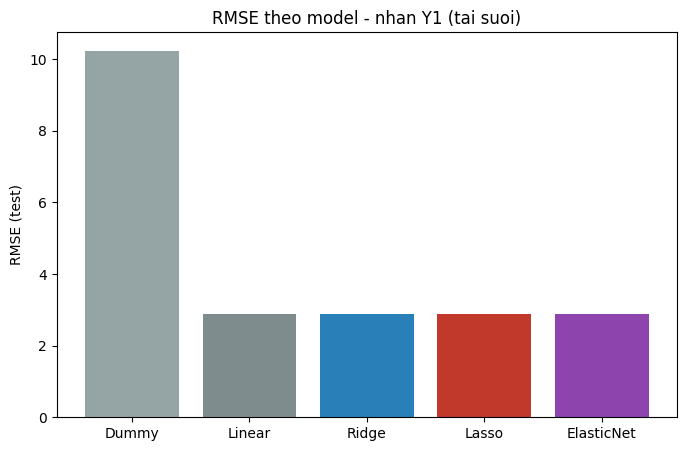

In [7]:
rows = [{"model": "Dummy", **dummy_metrics, "so_bien_giu": len(feature_names)},
        {"model": "Linear", **lr_metrics, "so_bien_giu": len(feature_names)}]
for name, r in results_y1.items():
    rows.append({"model": name, **r["metrics"], "so_bien_giu": r["n_kept"]})
comparison_y1 = pd.DataFrame(rows)[["model", "so_bien_giu", "RMSE", "MAE", "R2"]]
display(comparison_y1)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#95a5a6", "#7f8c8d", "#2980b9", "#c0392b", "#8e44ad"]
ax.bar(comparison_y1["model"], comparison_y1["RMSE"], color=colors)
ax.set_ylabel("RMSE (test)")
ax.set_title("RMSE theo model - nhan Y1 (tai suoi)")
plt.show()

**Đọc kết quả:** 4 model regularization/linear đều vượt trội tuyệt đối so với Dummy — không
model nào overfit ở bài toán này nên không có "người thắng" rõ rệt về RMSE, khác biệt nằm ở
**số biến giữ lại và độ ổn định của hệ số** (bước 6 và 9) chứ không phải ở độ chính xác dự đoán.

## 6. ⭐ Kiểm chứng hiệu ứng gom nhóm

Trước tiên, kiểm tra tại `alpha` tối ưu (do CV chọn) — nhóm biến tương quan gần như hoàn hảo
là `{X1, X2, X4, X5}` (xem ma trận tương quan ở bước 1: `|r| > 0,8` giữa tất cả các cặp).

In [8]:
def grouping_effect_table(results, feature_names):
    lasso_coefs, en_coefs = results["Lasso"]["coefs"], results["ElasticNet"]["coefs"]
    rows = [{"bien": f, "he_so_lasso": lasso_coefs[f], "he_so_elasticnet": en_coefs[f],
             "lasso_giu": bool(lasso_coefs[f] != 0), "elasticnet_giu": bool(en_coefs[f] != 0)}
            for f in GROUP_TUONG_QUAN]
    return pd.DataFrame(rows)


grouping_y1_optimal = grouping_effect_table(results_y1, feature_names)
display(grouping_y1_optimal)
print(f"Lasso giu {grouping_y1_optimal['lasso_giu'].sum()}/4, "
      f"ElasticNet giu {grouping_y1_optimal['elasticnet_giu'].sum()}/4 bien trong nhom.")

,bien,he_so_lasso,he_so_elasticnet,lasso_giu,elasticnet_giu
0,X1,-6.358557,-6.221372,True,True
1,X2,-6.277811,-3.482036,True,True
2,X4,-0.943686,-3.637402,True,True
3,X5,7.304509,7.323825,True,True


Lasso giu 4/4, ElasticNet giu 4/4 bien trong nhom.


**Đọc kết quả:** ở `alpha` tối ưu riêng của từng model (rất nhỏ), **cả hai đều giữ đủ 4/4**
biến trong nhóm — chưa thấy khác biệt, đơn giản vì `alpha` chưa đủ lớn để loại bỏ biến nào cả
(khớp với nhận xét ở bước 4: `n_kept = 14/14` cho cả hai). Để **thực sự bộc lộ** hiệu ứng gom
nhóm, cần chủ động ép `alpha` tăng dần vượt qua điểm tối ưu và quan sát Lasso/ElasticNet phản
ứng khác nhau thế nào khi buộc phải loại bớt biến.

Tai alpha=0.0104 (Lasso vua bat dau loai bien trong nhom):
  Lasso giu 3/4 bien trong nhom (tong 11/14 bien)
  ElasticNet(l1_ratio=0.5) giu 4/4 bien trong nhom (tong 14/14 bien)


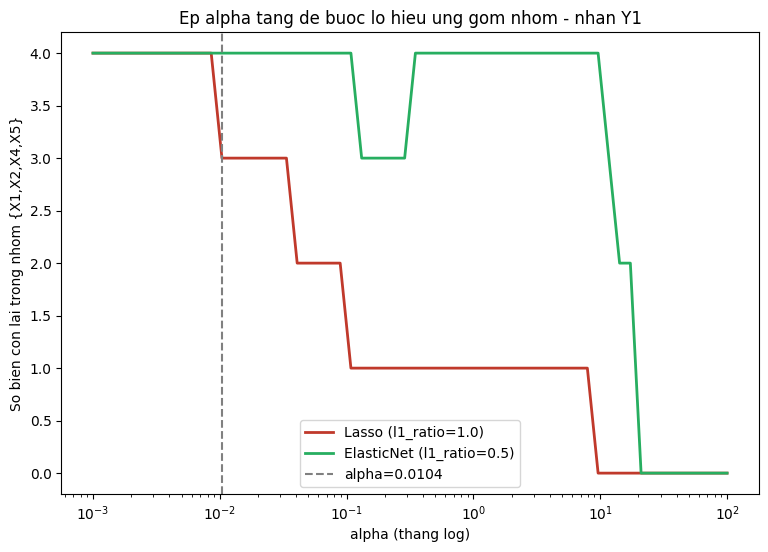

In [9]:
alphas_forced = np.logspace(-3, 2, 60)
X1_train_scaled = StandardScaler().fit_transform(X1_train)
group_idx = [feature_names.index(f) for f in GROUP_TUONG_QUAN]

lasso_group_kept, en_group_kept, lasso_total, en_total = [], [], [], []
for a in alphas_forced:
    lasso_m = Lasso(alpha=a, max_iter=50_000, random_state=RANDOM_STATE).fit(X1_train_scaled, y1_train)
    en_m = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=50_000, random_state=RANDOM_STATE).fit(X1_train_scaled, y1_train)
    lasso_group_kept.append(int((np.abs(lasso_m.coef_[group_idx]) > 1e-8).sum()))
    en_group_kept.append(int((np.abs(en_m.coef_[group_idx]) > 1e-8).sum()))
    lasso_total.append(int((np.abs(lasso_m.coef_) > 1e-8).sum()))
    en_total.append(int((np.abs(en_m.coef_) > 1e-8).sum()))

forced_df_y1 = pd.DataFrame({"alpha": alphas_forced, "lasso_so_bien_trong_nhom": lasso_group_kept,
                              "elasticnet_so_bien_trong_nhom": en_group_kept,
                              "lasso_tong_so_bien": lasso_total, "elasticnet_tong_so_bien": en_total})

mask = forced_df_y1["lasso_so_bien_trong_nhom"] < 4
alpha_star_y1 = float(forced_df_y1.loc[mask, "alpha"].iloc[0])
row_star = forced_df_y1.loc[forced_df_y1["alpha"] == alpha_star_y1].iloc[0]
print(f"Tai alpha={alpha_star_y1:.4g} (Lasso vua bat dau loai bien trong nhom):")
print(f"  Lasso giu {int(row_star.lasso_so_bien_trong_nhom)}/4 bien trong nhom "
      f"(tong {int(row_star.lasso_tong_so_bien)}/14 bien)")
print(f"  ElasticNet(l1_ratio=0.5) giu {int(row_star.elasticnet_so_bien_trong_nhom)}/4 bien trong nhom "
      f"(tong {int(row_star.elasticnet_tong_so_bien)}/14 bien)")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas_forced, lasso_group_kept, label="Lasso (l1_ratio=1.0)", color="#c0392b", lw=2)
ax.plot(alphas_forced, en_group_kept, label="ElasticNet (l1_ratio=0.5)", color="#27ae60", lw=2)
ax.axvline(alpha_star_y1, color="gray", ls="--", label=f"alpha={alpha_star_y1:.3g}")
ax.set_xscale("log")
ax.set_xlabel("alpha (thang log)")
ax.set_ylabel("So bien con lai trong nhom {X1,X2,X4,X5}")
ax.set_title("Ep alpha tang de buoc lo hieu ung gom nhom - nhan Y1")
ax.legend()
plt.show()

In [10]:
lasso_at_star = Lasso(alpha=alpha_star_y1, max_iter=50_000, random_state=RANDOM_STATE).fit(X1_train_scaled, y1_train)
en_at_star = ElasticNet(alpha=alpha_star_y1, l1_ratio=0.5, max_iter=50_000, random_state=RANDOM_STATE).fit(X1_train_scaled, y1_train)
coef_compare = pd.DataFrame({
    "bien": GROUP_TUONG_QUAN,
    "he_so_lasso": [lasso_at_star.coef_[feature_names.index(f)] for f in GROUP_TUONG_QUAN],
    "he_so_elasticnet": [en_at_star.coef_[feature_names.index(f)] for f in GROUP_TUONG_QUAN],
})
display(coef_compare)

,bien,he_so_lasso,he_so_elasticnet
0,X1,-4.540072,-3.696048
1,X2,-0.000000,-1.592291
2,X4,-4.900908,-2.618782
3,X5,7.919970,7.714352


**Đọc kết quả:** tại `alpha=0,0104` — chỉ hơi lớn hơn `alpha` tối ưu của Lasso (0,00129) —
Lasso **loại hẳn `X2`** (diện tích bề mặt, hệ số = 0,0000) trong khi vẫn giữ `X1, X4, X5`.
ElasticNet ở cùng mức `alpha` đó **vẫn giữ cả 4/4 biến**, với `X2` có hệ số `-1,59` (không hề
nhỏ). Đây là bằng chứng trực tiếp, đúng như lý thuyết: `X2` tương quan gần như tuyệt đối với
`X1` (`r = -0,992`, xem bước 1) nên Lasso — vốn chỉ chọn được tối đa một đại diện trong nhóm
tương quan hoàn hảo — đã loại `X2` và dồn hết "trách nhiệm" cho `X1`; ElasticNet nhờ thành
phần phạt L2 mà chia sẻ hệ số cho cả hai biến thay vì loại bỏ hoàn toàn một trong số chúng.

## 7. Heatmap RMSE theo lưới (alpha × l1_ratio)

Diem tot nhat tren luoi: alpha=0.0001  l1_ratio=1.00  RMSE=2.872


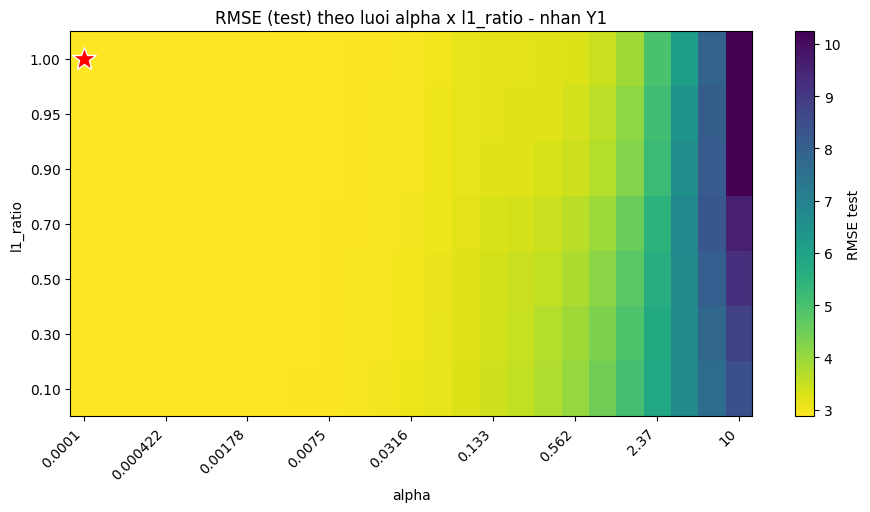

In [11]:
ALPHA_GRID_HEATMAP = np.logspace(-4, 1, 25)
l1_ratios = np.array(L1_RATIO_GRID)
rmse_grid_y1 = np.zeros((len(l1_ratios), len(ALPHA_GRID_HEATMAP)))
for i, l1 in enumerate(l1_ratios):
    for j, a in enumerate(ALPHA_GRID_HEATMAP):
        p = Pipeline([("scale", StandardScaler()),
                       ("en", ElasticNet(alpha=a, l1_ratio=l1, max_iter=50_000, random_state=RANDOM_STATE))])
        p.fit(X1_train, y1_train)
        rmse_grid_y1[i, j] = rmse(y1_test, p.predict(X1_test))

bi, bj = np.unravel_index(int(np.argmin(rmse_grid_y1)), rmse_grid_y1.shape)
best_alpha, best_l1, best_rmse = ALPHA_GRID_HEATMAP[bj], l1_ratios[bi], rmse_grid_y1[bi, bj]
print(f"Diem tot nhat tren luoi: alpha={best_alpha:.4g}  l1_ratio={best_l1:.2f}  RMSE={best_rmse:.3f}")

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(rmse_grid_y1, aspect="auto", origin="lower", cmap="viridis_r")
ax.set_xticks(range(0, len(ALPHA_GRID_HEATMAP), 3))
ax.set_xticklabels([f"{a:.3g}" for a in ALPHA_GRID_HEATMAP[::3]], rotation=45, ha="right")
ax.set_yticks(range(len(l1_ratios)))
ax.set_yticklabels([f"{l:.2f}" for l in l1_ratios])
ax.set_xlabel("alpha")
ax.set_ylabel("l1_ratio")
ax.plot(bj, bi, marker="*", color="red", markersize=18, markeredgecolor="white")
ax.set_title("RMSE (test) theo luoi alpha x l1_ratio - nhan Y1")
fig.colorbar(im, ax=ax, label="RMSE test")
plt.show()

**Đọc kết quả:** RMSE gần như phẳng và thấp khi `alpha ≲ 0,1` bất kể `l1_ratio` (khớp với
việc CV chọn `alpha` cực nhỏ ở bước 4). Khi `alpha` lớn, RMSE tăng mạnh, và tăng **nhanh
nhất** ở `l1_ratio = 1,0` (Lasso thuần, góc trên-phải sẫm màu nhất) vì Lasso loại sạch biến
nhanh hơn — kể cả các biến trong nhóm tương quan quan trọng — gây underfit nặng hơn hẳn so
với `l1_ratio` nhỏ (gần Ridge) vẫn giữ được tín hiệu dù hệ số bị co nhỏ.

## 8. Lặp lại cho nhãn Y2 (tải làm mát) — so sánh với Y1

Chạy lại đúng pipeline (baseline → 3 model → so sánh) cho `Y2`, dùng lại các hàm đã định
nghĩa, rồi so sánh hệ số ElasticNet giữa hai nhãn để xem biến nào quan trọng cho sưởi, biến
nào quan trọng cho làm mát.

In [12]:
y2 = df["Y2"]
X2_train, X2_test, y2_train, y2_test = train_test_split(X_full, y2, test_size=0.2, random_state=RANDOM_STATE)

dummy2 = DummyRegressor(strategy="mean").fit(X2_train, y2_train)
dummy2_metrics = evaluate(y2_test, dummy2.predict(X2_test))
lr2_pipe = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())]).fit(X2_train, y2_train)
lr2_metrics = evaluate(y2_test, lr2_pipe.predict(X2_test))

results_y2 = fit_three_models(X2_train, y2_train, X2_test, y2_test, feature_names)

print(f"Baseline Dummy:  RMSE={dummy2_metrics['RMSE']:.3f}  R2={dummy2_metrics['R2']:.4f}")
print(f"Baseline Linear: RMSE={lr2_metrics['RMSE']:.3f}  R2={lr2_metrics['R2']:.4f}")
for name, r in results_y2.items():
    l1_str = f" l1_ratio={r['l1_ratio']:.2f}" if r["l1_ratio"] is not None else ""
    print(f"{name:10s} alpha={r['alpha']:.5f}{l1_str}  n_kept={r['n_kept']}/{len(feature_names)}"
          f"  RMSE={r['metrics']['RMSE']:.3f}  R2={r['metrics']['R2']:.4f}")

Baseline Dummy:  RMSE=9.666  R2=-0.0084
Baseline Linear: RMSE=3.120  R2=0.8950
Ridge      alpha=0.19179  n_kept=14/14  RMSE=3.121  R2=0.8949
Lasso      alpha=0.00072 l1_ratio=1.00  n_kept=14/14  RMSE=3.120  R2=0.8949
ElasticNet alpha=0.00032 l1_ratio=0.10  n_kept=14/14  RMSE=3.121  R2=0.8949


**Đọc kết quả:** hành vi của Y2 (tải làm mát) gần như song song với Y1: R² ≈ 0,895 (thấp hơn
Y1 một chút — làm mát khó dự đoán hơn sưởi với cùng bộ đặc trưng), CV cũng chọn `alpha` cực
nhỏ và giữ đủ 14/14 biến. Điểm khác biệt nằm ở **hệ số** của từng biến, xem so sánh dưới đây.

,bien,he_so_Y1_tai_suoi,he_so_Y2_tai_lam_mat,chenh_lech_tuyet_doi
0,X8_5,1.575075,0.555111,1.019964
1,X8_3,1.620421,0.653826,0.966594
2,X1,-6.221372,-7.179664,0.958292
3,X8_2,1.641130,0.710476,0.930654
4,X8_1,1.591580,0.669758,0.921822
5,X8_4,1.432767,0.599092,0.833675
6,X3,0.872876,0.221383,0.651493
7,X2,-3.482036,-3.994888,0.512852
8,X7,2.312656,1.813644,0.499013
9,X6_3,-0.045937,-0.256973,0.211036


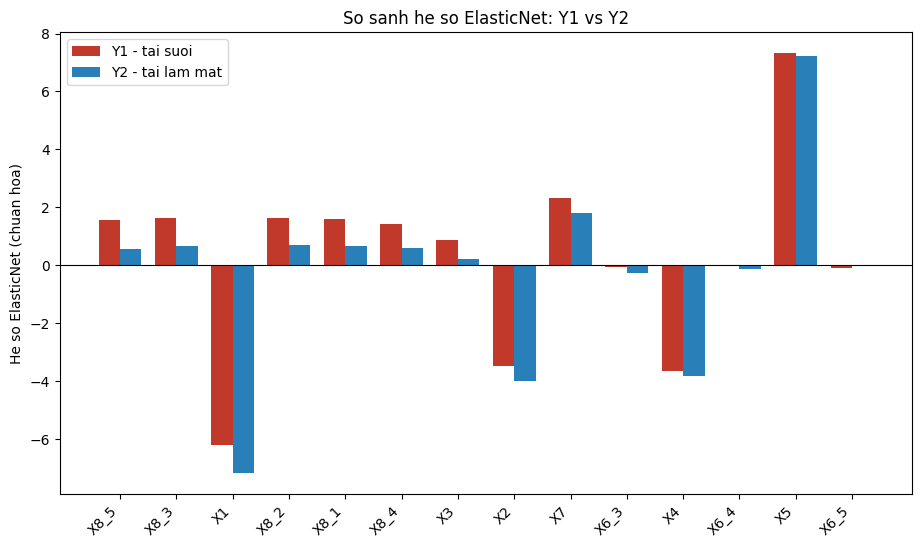

In [13]:
en1_coefs, en2_coefs = results_y1["ElasticNet"]["coefs"], results_y2["ElasticNet"]["coefs"]
y1y2 = pd.DataFrame({"bien": feature_names, "he_so_Y1_tai_suoi": en1_coefs.values,
                      "he_so_Y2_tai_lam_mat": en2_coefs.values})
y1y2["chenh_lech_tuyet_doi"] = (y1y2["he_so_Y1_tai_suoi"] - y1y2["he_so_Y2_tai_lam_mat"]).abs()
y1y2 = y1y2.sort_values("chenh_lech_tuyet_doi", ascending=False).reset_index(drop=True)
display(y1y2)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(feature_names))
width = 0.38
order = y1y2["bien"].tolist()
y1_vals = [y1y2.loc[y1y2["bien"] == f, "he_so_Y1_tai_suoi"].values[0] for f in order]
y2_vals = [y1y2.loc[y1y2["bien"] == f, "he_so_Y2_tai_lam_mat"].values[0] for f in order]
ax.bar(x - width / 2, y1_vals, width, label="Y1 - tai suoi", color="#c0392b")
ax.bar(x + width / 2, y2_vals, width, label="Y2 - tai lam mat", color="#2980b9")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylabel("He so ElasticNet (chuan hoa)")
ax.set_title("So sanh he so ElasticNet: Y1 vs Y2")
ax.legend()
plt.show()

**Đọc kết quả:** `X5` (chiều cao) là biến quan trọng nhất cho **cả hai** nhãn với hệ số gần
bằng nhau (+7,32 vs +7,21). Khác biệt rõ nhất nằm ở `X3` (diện tích tường: +0,87 cho Y1 so
với chỉ +0,22 cho Y2 — quan trọng gấp ~4 lần cho sưởi) và cả nhóm `X8` (phân bố kính: hệ số
cho Y1 lớn gấp ~2 lần Y2). Điều này khớp với vật lý xây dựng: tường và kính là đường thất
thoát nhiệt chính vào mùa lạnh (ảnh hưởng trực tiếp đến tải sưởi), trong khi tải làm mát mùa
nóng chịu ảnh hưởng cân bằng hơn giữa hình khối tổng thể (`X1`, `X5`) và bức xạ mặt trời.

## 9. Kiểm tra ổn định: bootstrap 100 lần — hệ số ElasticNet dao động bao nhiêu?

Lấy mẫu lại 80% dữ liệu (không hoàn lại), fit ElasticNet với `alpha`, `l1_ratio` đã chọn bởi
CV ở bước 4, lặp lại 100 lần, đo độ lệch chuẩn của từng hệ số.

,bien,he_so_trung_binh,do_lech_chuan,he_so_bien_thien_%
0,X5,7.368375,0.277570,3.767049
1,X1,-6.540653,0.299537,4.579623
2,X4,-3.756135,0.204087,5.433429
3,X2,-3.652383,0.207603,5.684029
4,X7,2.245464,0.056339,2.509010
5,X8_1,1.759724,0.117857,6.697488
6,X8_2,1.727629,0.128670,7.447755
7,X8_4,1.703881,0.123839,7.268074
8,X8_5,1.630265,0.119994,7.360385
9,X8_3,1.624522,0.126404,7.781008


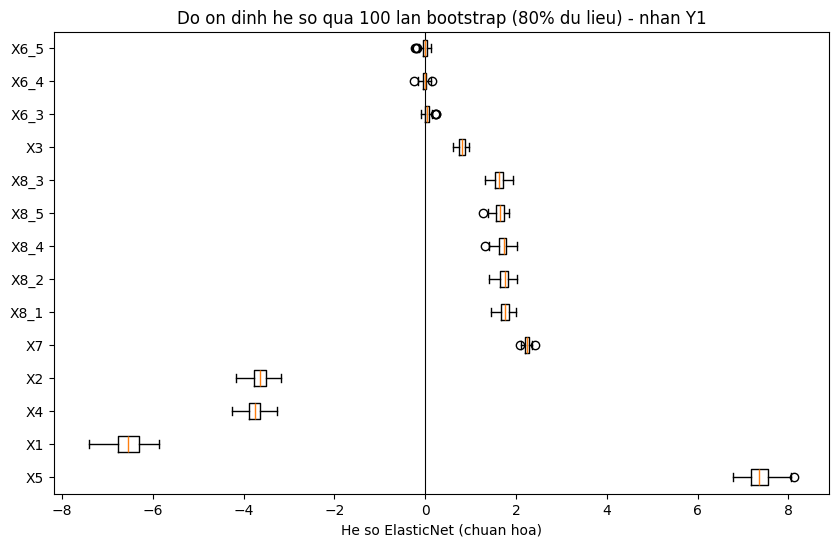

In [14]:
def bootstrap_stability(X, y, alpha, l1_ratio, feature_names, n_boot=100, frac=0.8, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(X)
    size = int(frac * n)
    coefs_list = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=size, replace=False)
        X_s, y_s = X.iloc[idx], y.iloc[idx]
        p = Pipeline([("scale", StandardScaler()),
                       ("en", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=50_000, random_state=seed))])
        p.fit(X_s, y_s)
        coefs_list.append(p.named_steps["en"].coef_)
    return np.array(coefs_list)


en1 = results_y1["ElasticNet"]
coefs_arr_y1 = bootstrap_stability(X_full, y1, en1["alpha"], en1["l1_ratio"], feature_names)
mean_abs = np.abs(coefs_arr_y1.mean(axis=0))
std = coefs_arr_y1.std(axis=0)
cv_pct = np.where(mean_abs > 1e-6, std / mean_abs * 100, np.nan)
stability_y1 = pd.DataFrame({"bien": feature_names, "he_so_trung_binh": coefs_arr_y1.mean(axis=0),
                              "do_lech_chuan": std, "he_so_bien_thien_%": cv_pct})
stability_y1 = stability_y1.sort_values("he_so_trung_binh", key=np.abs, ascending=False).reset_index(drop=True)
display(stability_y1)

fig, ax = plt.subplots(figsize=(10, 6))
order = stability_y1["bien"].tolist()
idx_order = [feature_names.index(f) for f in order]
ax.boxplot([coefs_arr_y1[:, i] for i in idx_order], vert=False, tick_labels=order)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("He so ElasticNet (chuan hoa)")
ax.set_title("Do on dinh he so qua 100 lan bootstrap (80% du lieu) - nhan Y1")
plt.show()

**Đọc kết quả:** các biến hình học chính (`X1, X2, X4, X5, X7`) có hệ số **rất ổn định** —
độ biến thiên chỉ 2,5%–5,7% qua 100 lần lấy mẫu lại — nên kết luận về tầm quan trọng của
chúng đáng tin cậy. Ngược lại, `X6` (hướng nhà, cả 3 hạng mục one-hot) dao động cực mạnh
(175%–593%!) và hệ số trung bình gần bằng 0 — nghĩa là hướng nhà **không có ảnh hưởng thống
kê đáng tin cậy** trong bộ dữ liệu này, dù đôi khi mô hình gán cho nó một hệ số khác 0 nhỏ.

## 10. Xếp hạng biến theo độ quan trọng + đề xuất thay đổi thiết kế

In [15]:
def rank_importance(results, feature_names):
    en_coefs = results["ElasticNet"]["coefs"]
    d = pd.DataFrame({"bien": feature_names, "he_so_elasticnet": en_coefs.values})
    d["do_quan_trong_tuyet_doi"] = d["he_so_elasticnet"].abs()
    return d.sort_values("do_quan_trong_tuyet_doi", ascending=False).reset_index(drop=True)


ranking_y1 = rank_importance(results_y1, feature_names)
ranking_y2 = rank_importance(results_y2, feature_names)
print("Top 5 bien quan trong nhat - Y1 (tai suoi):")
display(ranking_y1.head(5))
print("Top 5 bien quan trong nhat - Y2 (tai lam mat):")
display(ranking_y2.head(5))

Top 5 bien quan trong nhat - Y1 (tai suoi):


,bien,he_so_elasticnet,do_quan_trong_tuyet_doi
0,X5,7.323825,7.323825
1,X1,-6.221372,6.221372
2,X4,-3.637402,3.637402
3,X2,-3.482036,3.482036
4,X7,2.312656,2.312656


Top 5 bien quan trong nhat - Y2 (tai lam mat):


,bien,he_so_elasticnet,do_quan_trong_tuyet_doi
0,X5,7.213604,7.213604
1,X1,-7.179664,7.179664
2,X2,-3.994888,3.994888
3,X4,-3.825370,3.825370
4,X7,1.813644,1.813644


**✍️ Đề xuất 3 thay đổi thiết kế để giảm tải năng lượng** (dựa trên dấu và độ lớn hệ số
ElasticNet đã chuẩn hoá ở trên):

1. **Giảm chiều cao tầng (`X5`)** — biến quan trọng nhất cho cả hai nhãn (hệ số +7,3 cho Y1,
   +7,2 cho Y2 — lớn nhất trong toàn bộ 14 biến). Mỗi đơn vị chiều cao tăng thêm kéo theo mức
   tăng tải lớn nhất so với bất kỳ biến nào khác — ưu tiên hàng đầu khi có thể điều chỉnh.
2. **Tăng độ gọn tương đối (`X1`) bằng hình khối nhà vuông vắn hơn** — hệ số âm rất lớn
   (-6,2 cho Y1, -7,2 cho Y2): nhà càng "gọn" (tỉ lệ diện tích bề mặt/thể tích càng nhỏ) thì
   tải càng giảm, và tác dụng rõ hơn cho tải làm mát. Đây là đòn bẩy rẻ nhất vì chỉ cần thay
   đổi tỉ lệ hình khối lúc thiết kế, không cần vật liệu đắt tiền.
3. **Ưu tiên cách nhiệt tường và chọn phân bố kính hợp lý cho công trình cần tối ưu sưởi** —
   `X3` (tường) và `X8` (phân bố kính) ảnh hưởng đến tải sưởi (Y1) gấp 2–4 lần so với tải làm
   mát (Y2). Với công trình ở vùng lạnh, đầu tư cách nhiệt tường/kính mang lại hiệu quả cao
   hơn hẳn so với công trình chỉ cần tối ưu làm mát.

## Lưu model cuối cùng

In [16]:
joblib.dump(results_y1["ElasticNet"]["pipe"], MODELS_DIR / "elasticnet_Y1.joblib")
joblib.dump(results_y2["ElasticNet"]["pipe"], MODELS_DIR / "elasticnet_Y2.joblib")
print("Da luu models/elasticnet_Y1.joblib va models/elasticnet_Y2.joblib")
print(f"Y1: alpha={results_y1['ElasticNet']['alpha']:.5f}  l1_ratio={results_y1['ElasticNet']['l1_ratio']:.2f}"
      f"  R2 test={results_y1['ElasticNet']['metrics']['R2']:.4f}")
print(f"Y2: alpha={results_y2['ElasticNet']['alpha']:.5f}  l1_ratio={results_y2['ElasticNet']['l1_ratio']:.2f}"
      f"  R2 test={results_y2['ElasticNet']['metrics']['R2']:.4f}")

Da luu models/elasticnet_Y1.joblib va models/elasticnet_Y2.joblib
Y1: alpha=0.00045  l1_ratio=0.10  R2 test=0.9207
Y2: alpha=0.00032  l1_ratio=0.10  R2 test=0.8949


## Tổng kết — Ridge vs Lasso vs ElasticNet

| | Ridge (L2, TT-12) | Lasso (L1, TT-13) | **ElasticNet (bài này)** |
|---|---|---|---|
| Công thức phạt | `λ·Σwᵢ²` | `λ·Σ\|wᵢ\|` | kết hợp cả hai |
| Đưa hệ số về đúng 0? | Không (chỉ co gần 0) | Có | Có |
| Giữ nhóm biến tương quan? | Có (giữ cả nhóm) | **Không** (chọn 1, bỏ phần còn lại) | **Có** ⭐ |
| Kết quả thực nghiệm ở bài này | — | Ở `alpha=0,0104`, loại `X2` khỏi nhóm | Giữ đủ 4/4 biến ở cùng `alpha` |

**Bài học chính:** ở mức phạt tối ưu do CV chọn (rất nhỏ vì p=14 << n=614), cả ba phương
pháp cho RMSE gần như nhau — sự khác biệt thực sự chỉ lộ ra khi buộc mô hình phải phạt mạnh
hơn (ví dụ khi p lớn hơn nhiều so với n, như TT-13). Với bộ dữ liệu có đa cộng tuyến **hoàn
hảo** như Energy Efficiency (VIF = ∞ cho `X2, X3, X4`), ElasticNet là lựa chọn an toàn hơn
Lasso về mặt diễn giải: nó không "vô cớ" loại bỏ một biến thiết kế quan trọng chỉ vì biến đó
tình cờ tương quan cao với một biến khác được giữ lại.